In [ ]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# ============================================================
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ СБОРА
# ============================================================
def collect_city_banks(city_name_en, city_name_ru, lat_points, lon_points, 
                        queries=["банкомат", "отделение банка"], zoom=14):
    """
    Собирает банковские точки для одного города.
    
    Параметры:
        city_name_en: название города для URL (brest, vitebsk, gomel, grodno, mogilev)
        city_name_ru: название для вывода
        lat_points: список широт сетки
        lon_points: список долгот сетки
    """
    print(f"\n{'='*60}")
    print(f"🚀 СБОР: {city_name_ru}")
    print(f"{'='*60}")
    print(f"   Сетка: {len(lat_points)}x{len(lon_points)} = {len(lat_points)*len(lon_points)} квадратов")
    print(f"   Всего запросов: {len(lat_points)*len(lon_points)*len(queries)}")
    
    service = Service(ChromeDriverManager().install())
    options = Options()
    # options.add_argument("--headless")  # Раскомментируйте для фонового режима
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:151.0) Gecko/20100101 Firefox/151.0")
    
    driver = webdriver.Chrome(service=service, options=options)
    
    def scroll_until_end():
        """Прокручивает список до конца и собирает все элементы."""
        try:
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "ul.search-list-view__list"))
            )
        except:
            return []
        time.sleep(2)
        
        seen = set()
        data = []
        no_change = 0
        
        for i in range(50):
            items = driver.find_elements(By.CSS_SELECTOR, "ul.search-list-view__list > li")
            new = 0
            
            for item in items:
                try:
                    body = item.find_element(By.CSS_SELECTOR, "[data-coordinates]")
                    cid = body.get_attribute("data-id") or body.get_attribute("data-coordinates")
                    
                    if cid and cid not in seen:
                        seen.add(cid)
                        coords = body.get_attribute("data-coordinates")
                        
                        try:
                            name = item.find_element(By.CSS_SELECTOR, "[class*='name'], [class*='title']").text.strip()
                        except:
                            name = "N/A"
                        
                        try:
                            addr = item.find_element(By.CSS_SELECTOR, "[class*='address'], [class*='subtitle']").text.strip()
                        except:
                            addr = ""
                        
                        try:
                            cat = item.find_element(By.CSS_SELECTOR, "[class*='category']").text.strip()
                        except:
                            cat = ""
                        
                        lon, lat = coords.split(',')
                        data.append({
                            'name': name,
                            'address': addr,
                            'category': cat,
                            'lat': float(lat),
                            'lon': float(lon),
                        })
                        new += 1
                except:
                    continue
            
            if new == 0:
                no_change += 1
                if no_change >= 3:
                    break
            else:
                no_change = 0
            
            if items:
                driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", items[-1])
                time.sleep(2)
        
        return data
    
    total = len(lat_points) * len(lon_points) * len(queries)
    current = 0
    all_data = []
    
    for lat in lat_points:
        for lon in lon_points:
            for query in queries:
                current += 1
                print(f"   [{current}/{total}] {query} ({lat:.3f}, {lon:.3f})", end=' ')
                
                encoded = query.replace(' ', '%20')
                url = f"https://yandex.by/maps/157/{city_name_en}/search/{encoded}/?ll={lon}%2C{lat}&z={zoom}"
                driver.get(url)
                
                results = scroll_until_end()
                for r in results:
                    r['query'] = query
                all_data.extend(results)
                
                print(f"+{len(results)}")
                time.sleep(2)
    
    driver.quit()
    
    # Сохраняем
    df = pd.DataFrame(all_data)
    if len(df) > 0:
        df = df.drop_duplicates(subset=['name', 'address', 'lat', 'lon'])
        filename = f'{city_name_en}_banks.csv'
        df.to_csv(filename, index=False)
        print(f"   ✅ Сохранено: {filename} ({len(df)} уникальных точек)")
    else:
        print(f"   ⚠️ Ничего не собрано!")
    
    return df

# ============================================================
# ПАРАМЕТРЫ ГОРОДОВ
# ============================================================
# Формат: (имя_для_url, имя_для_вывода, [широты], [долготы])

cities_config = [
    # Минск — уже собран, пропускаем
    #('minsk', 'Минск', 
    # [53.81, 53.85, 53.89, 53.93, 53.97], 
    # [27.33, 27.41, 27.49, 27.57, 27.65, 27.74]),
    
    #('gomel', 'Гомель', 
    #[52.34, 52.38, 52.42, 52.46, 52.50], 
    #[30.80, 30.84, 30.88, 30.92, 30.96, 31.00, 31.04, 31.08, 31.12, 31.16]),
    
    #('brest', 'Брест', 
    # [52.02, 52.06, 52.10, 52.14], 
    # [23.56, 23.60, 23.64, 23.68, 23.72, 23.76,23.80, 23.86]),
    
    ('vitebsk', 'Витебск', 
     [55.13, 55.17, 55.21, 55.25, 55.29, 55.32], 
     [30.08, 30.12, 30.16, 30.20, 30.24, 30.28, 30.32]),
    
    ('grodno', 'Гродно', 
     [53.60, 53.64, 53.68, 53.72, 53.75], 
     [23.70, 23.74, 23.78, 23.82, 23.86, 23.90, 23.94, 23.98]),
    
    ('mogilev', 'Могилёв', 
     [53.79, 53.83, 53.87, 53.91, 53.95], 
     [30.22, 30.26, 30.30, 30.34, 30.38, 30.42, 30.46]),
]

# ============================================================
# ЗАПУСК СБОРА
# ============================================================
print("=" * 60)
print("🏦 СБОР БАНКОВСКИХ ТОЧЕК ПО ОБЛАСТНЫМ ЦЕНТРАМ БЕЛАРУСИ")
print("=" * 60)
print(f"Городов для сбора: {len(cities_config)}")
print(f"Общее время: ~{len(cities_config) * 20}-{len(cities_config) * 40} минут\n")

all_dfs = {}

for city_en, city_ru, lats, lons in cities_config:
    try:
        df = collect_city_banks(city_en, city_ru, lats, lons)
        all_dfs[city_ru] = df
        print(f"\n✅ {city_ru}: {len(df)} точек собрано\n")
    except Exception as e:
        print(f"\n❌ Ошибка в {city_ru}: {e}\n")

# ============================================================
# ИТОГИ СБОРА
# ============================================================
print("\n" + "=" * 60)
print("📊 ИТОГИ СБОРА:")
print("=" * 60)
total_points = 0
for city, df in all_dfs.items():
    print(f"   {city}: {len(df)} точек")
    total_points += len(df)
print(f"\n   Всего собрано: {total_points} точек")
print("   ✅ Сбор данных завершён!")
print("   📂 Файлы сохранены: gomel_banks.csv, brest_banks.csv, vitebsk_banks.csv, grodno_banks.csv, mogilev_banks.csv")

🏦 СБОР БАНКОВСКИХ ТОЧЕК ПО ОБЛАСТНЫМ ЦЕНТРАМ БЕЛАРУСИ
Городов для сбора: 3
Общее время: ~60-120 минут


🚀 СБОР: Витебск
   Сетка: 6x7 = 42 квадратов
   Всего запросов: 84
   [1/84] банкомат (55.130, 30.080) +3
   [2/84] отделение банка (55.130, 30.080) +0
   [3/84] банкомат (55.130, 30.120) +0
   [4/84] отделение банка (55.130, 30.120) +2
   [5/84] банкомат (55.130, 30.160) +0
   [6/84] отделение банка (55.130, 30.160) +12
   [7/84] банкомат (55.130, 30.200) +19
   [8/84] отделение банка (55.130, 30.200) +13
   [9/84] банкомат (55.130, 30.240) +0
   [10/84] отделение банка (55.130, 30.240) +0
   [11/84] банкомат (55.130, 30.280) +0
   [12/84] отделение банка (55.130, 30.280) +0
   [13/84] банкомат (55.130, 30.320) +7
   [14/84] отделение банка (55.130, 30.320) +2
   [15/84] банкомат (55.170, 30.080) +0
   [16/84] отделение банка (55.170, 30.080) +0
   [17/84] банкомат (55.170, 30.120) +11
   [18/84] отделение банка (55.170, 30.120) +2
   [19/84] банкомат (55.170, 30.160) +13
   [20/84]

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, MultiPoint
import numpy as np
import osmnx as ox

def analyze_city(city_name, banks_csv, lat_min, lat_max, lon_min, lon_max):
    """
    Полный пайплайн анализа доступности для одного города.
    """
    print(f"\n{'='*60}")
    print(f"🏙️ АНАЛИЗ: {city_name}")
    print(f"{'='*60}")
    
    # 1. Банки
    df = pd.read_csv(banks_csv)
    df = df[(df['lat'] > lat_min) & (df['lat'] < lat_max) & 
            (df['lon'] > lon_min) & (df['lon'] < lon_max)]
    
    def determine_type(row):
        combined = f"{row.get('category', '')} {row['query']}".lower()
        if 'банкомат' in combined: return 'atm'
        elif 'отделение' in combined or 'банк' in combined: return 'office'
        return 'unknown'
    
    df['type'] = df.apply(determine_type, axis=1)
    
    # Название банка
    def extract_bank(name):
        if pd.isna(name): return 'Неизвестно'
        name = str(name).strip().lower()
        banks_map = {
        'беларусбанк': 'Беларусбанк',
        'асб беларусбанк': 'Беларусбанк',
        'белагропромбанк': 'Белагропромбанк',
        'приорбанк': 'Приорбанк',
        'альфа-банк': 'Альфа-Банк',
        'альфа банк': 'Альфа-Банк',
        'альфа private': 'Альфа-Банк',
        'альфабанк, банкомат': 'Альфа-Банк',
        'белинвестбанк': 'Белинвестбанк',
        'мтбанк': 'МТБанк',
        'сбер банк': 'Сбер Банк',
        'сбер': 'Сбер Банк',
        'сбербанк': 'Сбер Банк',
        'сберБанк': 'Сбер Банк',
        'сбербизнес': 'Сбер Банк',
        'бпс-сбербанк': 'Сбер Банк',
        'сбер Первый': 'Сбер Банк',
        'бнб-банк': 'БНБ-Банк',
        'бнб': 'БНБ-Банк',
        'белвэб': 'БелВЭБ',
        'банк белвэб': 'БелВЭБ',
        'технобанк': 'Технобанк',
        'банк дабрабыт': 'Банк Дабрабыт',
        'белгазпромбанк': 'Белгазпромбанк',
        'банк втб': 'Банк ВТБ',
        'втб': 'Банк ВТБ',
        'бсб банк': 'БСБ Банк',
        'статус банк': 'Статус Банк',
        'атм белинвестбанк': 'Белинвестбанк',
        'франсабанк': 'Франсабанк',
        'банк Решение,': 'Банк Решение',
        'решение': 'Банк Решение',
        'абсолютбанк': 'Абсолютбанк',
        'цептер банк': 'Цептер Банк',
        'zepter bank': 'Цептер Банк',
        'zepter Bank': 'Цептер Банк',
        'bsb bank': 'БСБ Банк',
        'neo bank': 'Neo Bank',
        'идея банк': 'Идея Банк',
        'белорусский народный': 'БНБ-Банк',
        'банк торговый': 'Банк Торговый капитал',
        'ррб-банк': 'РРБ-Банк',
        'ррб': 'РРБ-Банк',
        'паритетбанк': 'Паритетбанк',
    }
        for key, value in banks_map.items():
            if key in name: return value
        return name[:40]
    
    df['bank_name'] = df['name'].apply(extract_bank)
    
    # Геодатафрейм
    geom = [Point(xy) for xy in zip(df['lon'], df['lat'])]
    gdf_banks = gpd.GeoDataFrame(df, geometry=geom, crs="EPSG:4326")
    
    print(f"   Точек: {len(gdf_banks)} (ATM: {len(gdf_banks[gdf_banks['type']=='atm'])}, Office: {len(gdf_banks[gdf_banks['type']=='office'])})")
    
    # 2. Дома из OSM
    print(f"   Выгружаем дома...")
    try:
        buildings = ox.features_from_place(f'{city_name}, Беларусь', tags={'building': True})
        residential = buildings[buildings['building'].isin([
            'apartments', 'residential', 'house', 'detached', 'yes'
        ])].copy()
        residential = residential[residential.geometry.type.isin(['Polygon', 'MultiPolygon'])]
    except:
        residential = ox.features_from_bbox(lat_max, lat_min, lon_max, lon_min, 
                                             tags={'building': True})
        residential = residential[residential['building'].isin([
            'apartments', 'residential', 'house', 'detached', 'yes'
        ])].copy()
        residential = residential[residential.geometry.type.isin(['Polygon', 'MultiPolygon'])]
    
    gdf_houses = residential.cx[lon_min:lon_max, lat_min:lat_max].copy()
    print(f"   Домов: {len(gdf_houses)}")
    
    # 3. Расстояния
    gdf_banks_m = gdf_banks.to_crs('EPSG:32635')
    gdf_houses_m = gdf_houses.to_crs('EPSG:32635')
    
    all_pts = MultiPoint(gdf_banks_m.geometry.tolist())
    office_pts = MultiPoint(gdf_banks_m[gdf_banks_m['type']=='office'].geometry.tolist()) if len(gdf_banks_m[gdf_banks_m['type']=='office'])>0 else None
    atm_pts = MultiPoint(gdf_banks_m[gdf_banks_m['type']=='atm'].geometry.tolist()) if len(gdf_banks_m[gdf_banks_m['type']=='atm'])>0 else None
    
    print(f"   Считаем расстояния...")
    dist_all, dist_office, dist_atm = [], [], []
    for idx, row in gdf_houses_m.iterrows():
        c = row.geometry.centroid
        dist_all.append(c.distance(all_pts))
        dist_office.append(c.distance(office_pts) if office_pts else np.nan)
        dist_atm.append(c.distance(atm_pts) if atm_pts else np.nan)
    
    gdf_houses['dist_all'] = dist_all
    gdf_houses['dist_office'] = dist_office
    gdf_houses['dist_atm'] = dist_atm
    
    # Категории
    def cat(d):
        if pd.isna(d): return 'Нет данных'
        if d <= 500: return 'Отлично'
        if d <= 1000: return 'Хорошо'
        if d <= 2000: return 'Удовл.'
        return 'Плохо'
    
    for col, mode in [('dist_all', 'all'), ('dist_office', 'office'), ('dist_atm', 'atm')]:
        gdf_houses[f'cat_{mode}'] = gdf_houses[col].apply(cat)
    
    # Статистика
    stats = {}
    for mode in ['all', 'office', 'atm']:
        counts = gdf_houses[f'cat_{mode}'].value_counts().to_dict()
        total = len(gdf_houses)
        stats[mode] = {
            'total': total,
            'excellent': counts.get('Отлично', 0),
            'good': counts.get('Хорошо', 0),
            'ok': counts.get('Удовл.', 0),
            'bad': counts.get('Плохо', 0),
        }
    
    # Сохраняем
    gdf_houses.to_file(f'{city_name.lower()}_accessibility.geojson', driver='GeoJSON')
    gdf_banks.to_file(f'{city_name.lower()}_banks.geojson', driver='GeoJSON')
    
    return stats

# ============================================================
# ЗАПУСК ДЛЯ ВСЕХ ГОРОДОВ
# ============================================================

cities = {
    'Минск': ('minsk_banks.csv', 53.81, 53.97, 27.39, 27.74),
    'Гомель': ('gomel_banks.csv', 52.34, 52.50, 30.80, 31.16),
    'Брест': ('brest_banks.csv', 52.02, 52.14, 23.56, 23.86),
    'Витебск': ('vitebsk_banks.csv', 55.13, 55.32, 30.08, 30.32),
    'Гродно': ('grodno_banks.csv', 53.60, 53.75, 23.70, 23.98),
    'Могилёв': ('mogilev_banks.csv', 53.79, 53.95, 30.22, 30.46),
}

all_stats = {}
for city, (csv_file, lat_min, lat_max, lon_min, lon_max) in cities.items():
    try:
        stats = analyze_city(city, csv_file, lat_min, lat_max, lon_min, lon_max)
        all_stats[city] = stats
    except Exception as e:
        print(f"   ❌ Ошибка в {city}: {e}")

# ============================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================
print(f"\n\n{'='*80}")
print(f"📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ ДОСТУПНОСТИ БАНКОВСКИХ УСЛУГ")
print(f"{'='*80}")

print(f"\n{'Город':<12} {'Точек':<8} {'Домов':<8} {'Отлично':<10} {'Хорошо':<10} {'Удовл.':<10} {'Плохо':<10}")
print("-" * 68)

summary_rows = []
for city, stats in all_stats.items():
    s = stats['all']
    row = {
        'Город': city,
        'Точек': s['total'] if city == 'Минск' else len(pd.read_csv(cities[city][0])),
        'Домов': s['total'],
        'Отлично': f"{s['excellent']/s['total']*100:.1f}%",
        'Хорошо': f"{s['good']/s['total']*100:.1f}%",
        'Удовл.': f"{s['ok']/s['total']*100:.1f}%",
        'Плохо': f"{s['bad']/s['total']*100:.1f}%",
    }
    summary_rows.append(row)
    print(f"{city:<12} {row['Точек']:<8} {row['Домов']:<8} {row['Отлично']:<10} {row['Хорошо']:<10} {row['Удовл.']:<10} {row['Плохо']:<10}")

# Сохраняем сводную таблицу
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('belarus_banking_accessibility_summary.csv', index=False)
print(f"\n💾 Сводная таблица сохранена: belarus_banking_accessibility_summary.csv")

# Сохраняем всю статистику для дашборда
import json
with open('all_cities_stats.json', 'w', encoding='utf-8') as f:
    json.dump(all_stats, f, ensure_ascii=False)
print(f"💾 Полная статистика сохранена: all_cities_stats.json")


🏙️ АНАЛИЗ: Минск
   Точек: 1786 (ATM: 1359, Office: 427)
   Выгружаем дома...
   Домов: 42172
   Считаем расстояния...

🏙️ АНАЛИЗ: Гомель
   Точек: 491 (ATM: 399, Office: 92)
   Выгружаем дома...
   Домов: 32833
   Считаем расстояния...

🏙️ АНАЛИЗ: Брест
   Точек: 381 (ATM: 289, Office: 92)
   Выгружаем дома...
   Домов: 34207
   Считаем расстояния...

🏙️ АНАЛИЗ: Витебск
   Точек: 278 (ATM: 221, Office: 57)
   Выгружаем дома...


c:\Users\Grinskirm\Desktop\Notebooks\Bank coverage\venv\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 19 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


   Домов: 66112
   Считаем расстояния...

🏙️ АНАЛИЗ: Гродно
   Точек: 375 (ATM: 283, Office: 92)
   Выгружаем дома...
   Домов: 20812
   Считаем расстояния...

🏙️ АНАЛИЗ: Могилёв
   Точек: 415 (ATM: 350, Office: 65)
   Выгружаем дома...
   Домов: 36250
   Считаем расстояния...


📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ ДОСТУПНОСТИ БАНКОВСКИХ УСЛУГ

Город        Точек    Домов    Отлично    Хорошо     Удовл.     Плохо     
--------------------------------------------------------------------
Минск        42172    42172    65.4%      25.7%      8.2%       0.7%      
Гомель       502      32833    40.6%      35.3%      10.6%      13.6%     
Брест        389      34207    34.4%      38.0%      20.5%      7.1%      
Витебск      280      66112    22.3%      30.1%      26.6%      21.0%     
Гродно       378      20812    32.8%      31.1%      18.8%      17.2%     
Могилёв      423      36250    33.9%      35.9%      20.1%      10.1%     

💾 Сводная таблица сохранена: belarus_banking_accessibility_summary.csv
💾

✅ График плохой доступности сохранён (контрастные цвета)
✅ Интерактивный график сохранён (исправленная легенда)

🗺️ Генерируем карты доступности для всех городов...
   🏙️ Минск... ✅
   🏙️ Гомель... ✅
   🏙️ Брест... ✅
   🏙️ Витебск... ✅
   🏙️ Гродно... ✅
   🏙️ Могилёв... ✅

✅ Все карты сохранены с контрастными цветами!

📂 Итоговые файлы проекта:
   📊 Графики:
      • banking_accessibility_comparison.png — сравнение доступности
      • bad_accessibility_comparison.png — плохая доступность (контраст)
      • bank_density.png — плотность банков
      • banking_comparison_interactive.html — интерактивный Plotly
   🗺️ Карты городов:
      • минск_accessibility_map.html — карта Минск
      • гомель_accessibility_map.html — карта Гомель
      • брест_accessibility_map.html — карта Брест
      • витебск_accessibility_map.html — карта Витебск
      • гродно_accessibility_map.html — карта Гродно
      • могилёв_accessibility_map.html — карта Могилёв
   📋 Данные:
      • all_cities_stats.json — по

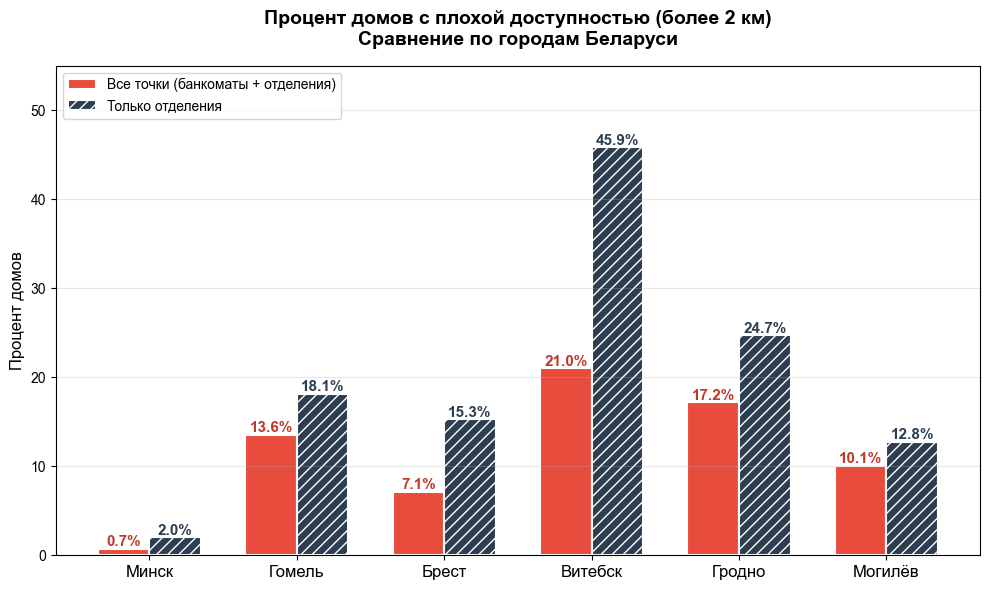

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'

with open('all_cities_stats.json', 'r', encoding='utf-8') as f:
    all_stats = json.load(f)

cities_order = ['Минск', 'Гомель', 'Брест', 'Витебск', 'Гродно', 'Могилёв']
categories = ['Отлично', 'Хорошо', 'Удовл.', 'Плохо']
colors_all = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
population = {
    'Минск': 1_992_862, 'Гомель': 501_802, 'Брест': 342_461,
    'Витебск': 358_395, 'Гродно': 361_352, 'Могилёв': 353_110,
}

cities_list = [c for c in cities_order if c in all_stats]
bad_all = [all_stats[c]['all']['bad'] / all_stats[c]['all']['total'] * 100 for c in cities_list]
bad_office = [all_stats[c]['office']['bad'] / all_stats[c]['office']['total'] * 100 for c in cities_list]

# ============================================================
# 1. ГРАФИК ПЛОХОЙ ДОСТУПНОСТИ — КОНТРАСТНЫЕ ЦВЕТА
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(cities_list))
width = 0.35

bars1 = ax.bar(x - width/2, bad_all, width, label='Все точки (банкоматы + отделения)', 
               color='#e74c3c', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, bad_office, width, label='Только отделения', 
               color='#2c3e50', edgecolor='white', linewidth=1.5, hatch='///')

for bar, val in zip(bars1, bad_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#c0392b')

for bar, val in zip(bars2, bad_office):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

ax.set_title('Процент домов с плохой доступностью (более 2 км)\nСравнение по городам Беларуси', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cities_list, fontsize=12)
ax.set_ylabel('Процент домов', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(bad_all), max(bad_office)) * 1.2)

plt.tight_layout()
plt.savefig('bad_accessibility_comparison.png', dpi=150, bbox_inches='tight')
print("✅ График плохой доступности сохранён (контрастные цвета)")

# ============================================================
# 2. ИНТЕРАКТИВНЫЙ PLOTLY — ИСПРАВЛЕННАЯ ЛЕГЕНДА
# ============================================================
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Все точки', 'Отделения', 'Плохая доступность', 'Плотность на 100к жит.'),
        specs=[[{'type': 'bar'}, {'type': 'bar'}], [{'type': 'bar'}, {'type': 'bar'}]],
        vertical_spacing=0.12,
        horizontal_spacing=0.10,
    )
    
    # Подграфик 1: Все точки
    for i, (cat, color) in enumerate(zip(categories, colors_all)):
        values = []
        for city in cities_list:
            s = all_stats[city]['all']
            values.append(s[['excellent', 'good', 'ok', 'bad'][i]] / s['total'] * 100)
        
        fig.add_trace(
            go.Bar(
                name=cat, x=cities_list, y=values, 
                marker_color=color,
                text=[f'{v:.0f}%' if v > 4 else '' for v in values], 
                textposition='inside', textfont=dict(size=10, color='white'),
                legendgroup='group1',
                showlegend=True,
            ),
            row=1, col=1
        )
    
    # Подграфик 2: Отделения
    for i, (cat, color) in enumerate(zip(categories, colors_all)):
        values = []
        for city in cities_list:
            s = all_stats[city]['office']
            values.append(s[['excellent', 'good', 'ok', 'bad'][i]] / s['total'] * 100)
        
        fig.add_trace(
            go.Bar(
                name=cat, x=cities_list, y=values, 
                marker_color=color,
                text=[f'{v:.0f}%' if v > 4 else '' for v in values], 
                textposition='inside', textfont=dict(size=10, color='white'),
                legendgroup='group1',
                showlegend=False,
            ),
            row=1, col=2
        )
    
    # Подграфик 3: Плохая доступность
    fig.add_trace(
        go.Bar(
            name='Все точки', x=cities_list, y=bad_all, 
            marker_color='#e74c3c', legendgroup='group2',
            text=[f'{v:.1f}%' for v in bad_all], textposition='outside',
        ),
        row=2, col=1
    )
    fig.add_trace(
        go.Bar(
            name='Только отделения', x=cities_list, y=bad_office, 
            marker_color='#2c3e50', legendgroup='group2',
            text=[f'{v:.1f}%' for v in bad_office], textposition='outside',
        ),
        row=2, col=1
    )
    
    # Подграфик 4: Плотность
    density = []
    for city in cities_list:
        csv_map = {
            'Минск': 'minsk_banks.csv', 'Гомель': 'gomel_banks.csv',
            'Брест': 'brest_banks.csv', 'Витебск': 'vitebsk_banks.csv',
            'Гродно': 'grodno_banks.csv', 'Могилёв': 'mogilev_banks.csv',
        }
        try:
            df = pd.read_csv(csv_map[city])
            count = len(df)
        except:
            count = 0
        density.append(count / population.get(city, 1) * 100_000)
    
    fig.add_trace(
        go.Bar(
            name='Точек на 100к жит.', x=cities_list, y=density,
            marker_color=['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e74c3c'],
            legendgroup='group3',
            text=[f'{v:.0f}' for v in density], textposition='outside',
        ),
        row=2, col=2
    )
    
    fig.update_layout(
        title='Сравнительный анализ банковской доступности — Беларусь',
        height=800,
        barmode='stack',
        template='plotly_dark',
        font=dict(family='Arial', size=12),
        legend=dict(
            title='Категории доступности:',
            orientation='h',
            yanchor='bottom', y=1.02,
            xanchor='center', x=0.5,
        ),
    )
    
    fig.update_traces(showlegend=False, row=2, col=1)
    fig.update_traces(showlegend=False, row=2, col=2)
    
    fig.write_html('banking_comparison_interactive.html')
    print("✅ Интерактивный график сохранён (исправленная легенда)")
    
except ImportError:
    print("⚠️ Plotly не установлен.")

# ============================================================
# 3. КАРТЫ ДОСТУПНОСТИ ДЛЯ ВСЕХ ГОРОДОВ
# ============================================================
print("\n🗺️ Генерируем карты доступности для всех городов...")

import folium
import geopandas as gpd

city_coords = {
    'Минск':   (53.90, 27.56),
    'Гомель':  (52.43, 30.98),
    'Брест':   (52.09, 23.70),
    'Витебск': (55.19, 30.20),
    'Гродно':  (53.68, 23.83),
    'Могилёв': (53.90, 30.34),
}

color_map = {
    'Отлично': '#2ecc71',
    'Хорошо': '#f1c40f',
    'Удовл.': '#e67e22',
    'Плохо': '#e74c3c',
}

for city in cities_list:
    print(f"   🏙️ {city}...", end=' ')
    
    try:
        gdf_houses = gpd.read_file(f'{city.lower()}_accessibility.geojson')
        gdf_banks = gpd.read_file(f'{city.lower()}_banks.geojson')
        
        center = city_coords.get(city, (53.9, 27.56))
        m = folium.Map(location=center, zoom_start=13 if city != 'Минск' else 12, 
                       tiles='CartoDB dark_matter')
        
        # Выборка каждого 3-го дома
        gdf_sample = gdf_houses.iloc[::3].copy()
        gdf_m = gdf_sample.to_crs('EPSG:32635')
        centroids_m = gdf_m.geometry.centroid
        centroids = gpd.GeoSeries(centroids_m, crs='EPSG:32635').to_crs('EPSG:4326')
        
        lats = centroids.y.values
        lons = centroids.x.values
        cats = gdf_sample['cat_all'].values
        
        # Дома по категориям
        for cat, color in color_map.items():
            mask = cats == cat
            if mask.sum() == 0:
                continue
            
            fg = folium.FeatureGroup(name=f'{cat} ({mask.sum()})')
            cat_lats, cat_lons = lats[mask], lons[mask]
            
            for i in range(len(cat_lats)):
                folium.CircleMarker(
                    location=[cat_lats[i], cat_lons[i]],
                    radius=2.5,
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.5,
                    weight=0.3,
                ).add_to(fg)
            
            fg.add_to(m)
        
                # Банки — ФИОЛЕТОВЫЙ для отделений, СИНИЙ для банкоматов + БЕЛАЯ ОБВОДКА
        bank_fg = folium.FeatureGroup(name='Банки')
        for idx, row in gdf_banks.iterrows():
            icon_color = '#8e44ad' if row['type'] == 'office' else '#2980b9'
            icon_label = 'Отделение' if row['type'] == 'office' else 'Банкомат'
            
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=6,
                color='white',        # Белая обводка
                weight=2,             # Толщина обводки
                fill=True,
                fill_color=icon_color,
                fill_opacity=1.0,
                popup=f"<b>{row.get('bank_name', '')}</b><br>{icon_label}<br>{row.get('address', '')}",
            ).add_to(bank_fg)
        bank_fg.add_to(m)
        
        # Легенда
        legend_html = f'''
        <div style="position: fixed; bottom: 50px; left: 50px; z-index:1000; 
        background: rgba(22,33,62,0.9); color: white; padding: 15px; 
        border-radius: 8px; font-family: Arial; font-size: 13px;">
        <b>🏦 {city} — Доступность банков</b><br>
        <small>{len(gdf_houses)} домов, {len(gdf_banks)} точек</small><br><br>
        <span style="color:#2ecc71;">●</span> Отлично (до 500м)<br>
        <span style="color:#f1c40f;">●</span> Хорошо (500м–1км)<br>
        <span style="color:#e67e22;">●</span> Удовлетворительно (1–2км)<br>
        <span style="color:#e74c3c;">●</span> Плохо (более 2км)<br>
        <hr>
        <span style="color:#8e44ad;">●</span> Отделение<br>
        <span style="color:#2980b9;">●</span> Банкомат
        </div>
        '''
        m.get_root().html.add_child(folium.Element(legend_html))
        folium.LayerControl().add_to(m)
        
        m.save(f'{city.lower()}_accessibility_map.html')
        print(f"✅")
        
    except FileNotFoundError:
        print(f"⚠️ Нет файлов")
    except Exception as e:
        print(f"❌ {type(e).__name__}: {e}")

print("\n✅ Все карты сохранены с контрастными цветами!")
print("\n📂 Итоговые файлы проекта:")
print("   📊 Графики:")
print("      • banking_accessibility_comparison.png — сравнение доступности")
print("      • bad_accessibility_comparison.png — плохая доступность (контраст)")
print("      • bank_density.png — плотность банков")
print("      • banking_comparison_interactive.html — интерактивный Plotly")
print("   🗺️ Карты городов:")
for city in cities_list:
    print(f"      • {city.lower()}_accessibility_map.html — карта {city}")
print("   📋 Данные:")
print("      • all_cities_stats.json — полная статистика")
print("      • final_summary.csv — сводная таблица")
print("      • *_banks.csv — данные о банках")
print("      • *_accessibility.geojson — геоданные доступности")

print(f"\n{'='*60}")
print("🏁 ПРОЕКТ ПОЛНОСТЬЮ ЗАВЕРШЁН!")
print(f"{'='*60}")